**OVERALL TASK**


You are a data analyst working for a tech company closely monitoring the AI tools market. You want to understand the evolving popularity of three major AI tools, ChatGPT, Gemini, and Microsoft Copilot, and identify which tool is gaining the most traction and how they compare over time.



You'll work with real-world time series data that captures the global interest in these tools over several weeks. Your goal is to analyze this data, uncover patterns, and provide actionable insights to help your company make informed decisions. This might include determining where to focus marketing efforts, predicting future trends, or identifying potential areas for improvement.

Are you ready to help your company stay ahead of the curve in the competitive AI tools market? Let's get started!

The Data
The Google Trends data is available as a CSV file ai_tools_comparison.csv. The data contains the number of worldwide searches for chatGpt, Gemini, and Microsoft Copilot over the past 12 months as of September 2024.

**Task 1**
Your goal is to extract meaningful insights from the search data by answering the following questions.

Which AI tool has shown the most consistent growth in interest over the observed period (the full dataset)? Save the name of the tool as most_consistent_tool of type Data type: string.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Inspect the data
trends.head(15)

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1
5,2023-10-01,67,3,1
6,2023-10-08,68,4,1
7,2023-10-15,69,4,1
8,2023-10-22,71,4,2
9,2023-10-29,69,3,2


.pct_change() useful for checking relative differeence(similiar to thee concept of relative error). it shows how much growth is made for each column, using thee previous enetry and comparing it to the current enetry. (assuming this dataframe is in order)

In [3]:
import numpy as np
#turn week column into datetime object and set it as index
trends['week'] = pd.to_datetime(trends['week'])
trends.set_index('week', inplace=True) 
growth_rates = trends[['chatgpt', 'gemini', 'microsoft_copilot']].pct_change().dropna()
growth_rates.head(15)

,chatgpt,gemini,microsoft_copilot
week,,,
2023-09-03,0.000000,0.000000,0.000000
2023-09-10,0.125000,0.000000,0.000000
2023-09-17,0.015873,0.000000,0.000000
2023-09-24,0.031250,0.000000,0.000000
2023-10-01,0.015152,0.000000,0.000000
2023-10-08,0.014925,0.333333,0.000000
2023-10-15,0.014706,0.000000,0.000000
2023-10-22,0.028986,0.000000,1.000000
2023-10-29,-0.028169,-0.250000,0.000000


0's shows no growth.
positive values shows increase in growth (i.e 56 to 63 gives 0.125 which is a 12.5% growth rate)
negative shows declinee in growth.
Show far chatgpt seems to have the most consisteent growth.

Now we can also combine this with .std(). Currently chatgpt is the beest canidate, but .std() will confirm if its consistent. 
low std = best consistenecy

In [4]:
std_ai = growth_rates.std()
most_consistent_tool = std_ai.idxmin()#grabs the index of lowest value
most_consistent_tool 

'chatgpt'

chatgpt has most consisteent growth. (error here, have to convert to string)

In [5]:
most_consistent_tool = str(most_consistent_tool)

**TASK 2**
Create a visualization showing the interest levels of ChatGPT, Gemini, and Microsoft Copilot over time. Around which month and year does ChatGPT experience its largest decline in interest? Save as gpt_dip of type string in the format "Month YYYY".

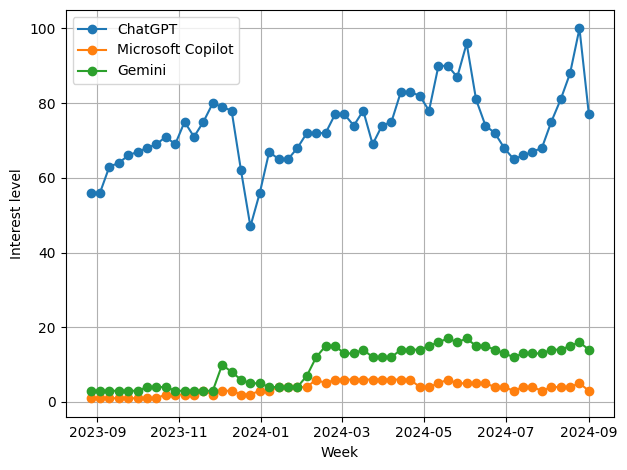

biggest decline we seene is 2024-09-01 00:00:00


In [7]:
#import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 

plt.plot(trends.index, trends['chatgpt'], label='ChatGPT', marker='o')
plt.plot(trends.index, trends['microsoft_copilot'], label='Microsoft Copilot', marker='o')
plt.plot(trends.index, trends['gemini'], label='Gemini', marker='o')
plt.xlabel('Week')
plt.ylabel('Interest level')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


chatgpt_decline = trends['chatgpt'].diff()
largest_decline_interest = chatgpt_decline.idxmin()


print(f"biggest decline we seene is {largest_decline_interest}")

# plt.plot(trends['week'], trends['chatgpt'], label=['ChatGpt'], marker='o')
# plt.plot(trends['week'], trends['microsoft_copilot'], label=['MicroSoft Copilot'], marker='o')
# plt.plot(trends['week'], trends['gemini'], label=['Gemini'], marker='o') 
# plt.xlabel('Week')
# plt.ylabel('Interest level')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# #diff() fo
# #min() for min value, idxmin() where is min valuee as index

# chatgpt_decline = trends['chatgpt'].diff()
# largest_decline_interest = chatgpt_decline.idxmin()
# print(f"biggest decline we seene is {largest_decline_interest}")


In [8]:
lowest_value_index = trends['chatgpt'].idxmin()
lowest_date = lowest_value_index
gpt_dip = lowest_date.strftime('%B %Y')
# gpt_dip = largest_decline_interest.strftime('%B %Y')
# gpt_dip = gpt_dip.index.to_period('M').astype(str)
print(gpt_dip)

December 2023


**Task 3** Explore the seasonality in the data by breaking it down into monthly averages. What month had the highest average interest across all tools? Save the month as best_month as type string.

In [10]:

month_data = trends[['chatgpt', 'gemini', 'microsoft_copilot']].resample('ME').mean()


month_data['avg_all'] = month_data.mean(axis=1)
month_data = month_data.sort_values(by='avg_all', ascending=False)


best_month_date = month_data.index[0]
best_month = best_month_date.strftime('%B') #only give month value
print(best_month)
#month column needed
# trends['month'] = trends.index.to_period('M').astype(str)
# month_avg =  trends.groupby('month')[['chatgpt','gemini','microsoft_copilot']].mean()
# month_avg['tools'] = month_avg.mean(axis=1)

# best_month = month_avg['tools'].idxmax()
# best_month

May
